# STEP.1 Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# STEP2: Load dataset

In [5]:
df=pd.read_csv("archive (3).zip")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

# STEP3:Understand the Data

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.shape

(545, 13)

In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.describe().mean()

price        4.399714e+06
area         5.034460e+03
bedrooms     7.046290e+01
bathrooms    6.947359e+01
stories      6.970912e+01
parking      6.881940e+01
dtype: float64

# STEP4:EDA

In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


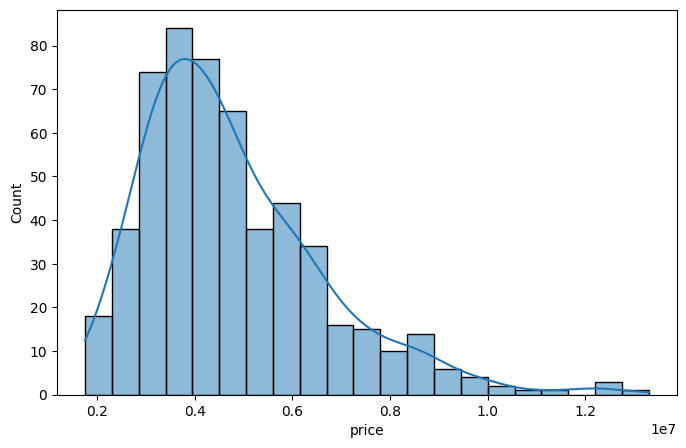

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"],kde=True)
plt.show()

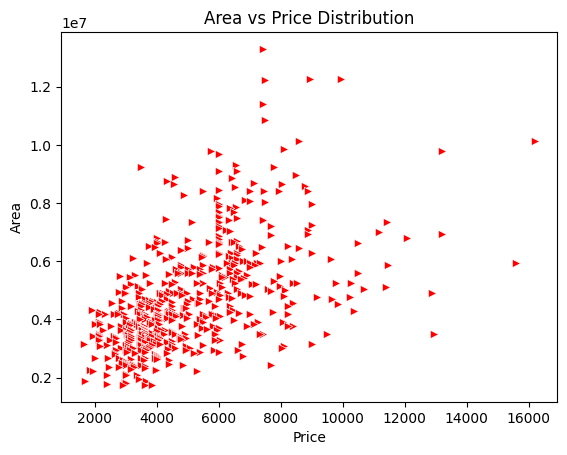

In [15]:
sns.scatterplot(x="area",y="price", color="red",marker=">",data=df)
plt.title("Area vs Price Distribution")
plt.xlabel("Price")
plt.ylabel("Area")
plt.legend

plt.show()

In [17]:
df.replace({"yes": 1, "no": 0}, inplace=True)

C:\Users\NEW\AppData\Local\Temp\ipykernel_11164\3136251882.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"yes": 1, "no": 0}, inplace=True)


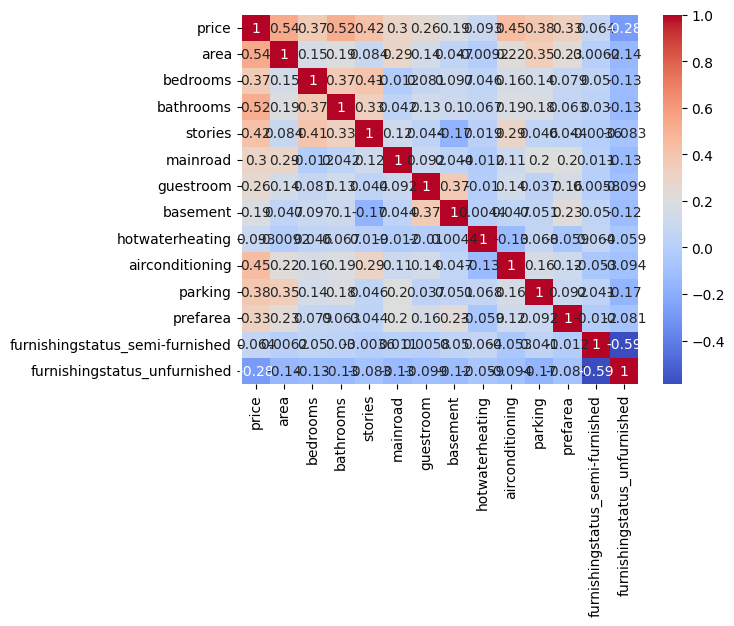

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True)

sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.show()

# STEP6: Feature Enginerrring

In [22]:
df_encoded = pd.get_dummies(df, drop_first=True)

# STEP7:Train Test Split

In [43]:
from sklearn.model_selection import train_test_split

X=df.drop("price",axis=1)
y=df["price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

# STEP8:Train the model

In [46]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [49]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [50]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [52]:
# Encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# STEP10: Advanced Evalution

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 813764.5177523674
MSE: 1159451901408.728
RMSE: 1076778.4829800082
R2 Score: 0.7043890880744688


# STEP11:Compare Original vs Predicated

In [57]:
result=pd.DataFrame({
    "Actual":y_test,
    "Predicated":y_pred
})

result.head()

,Actual,Predicated
41,7840000,7.570437e+06
419,3360000,4.072686e+06
190,5040000,6.195365e+06
143,5600000,6.031659e+06
163,5425000,6.048933e+06


# STEP12:Plot actuval vs predicted

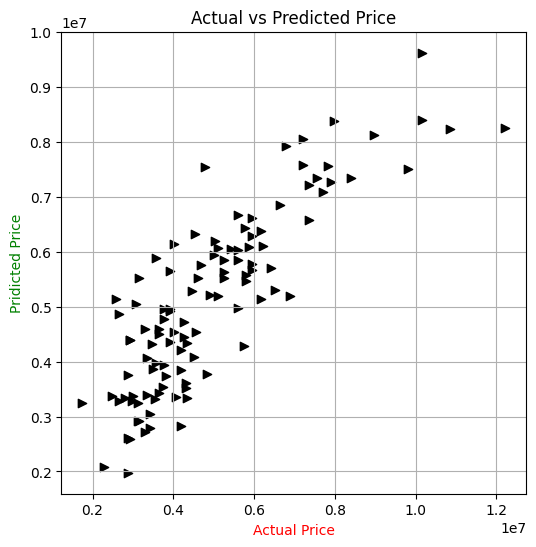

In [63]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred , color="black",marker=">")
plt.xlabel("Actual Price" ,color="red")
plt.ylabel("Pridicted Price" , color="green")
plt.title("Actual vs Predicted Price")
plt.grid()
plt.show()

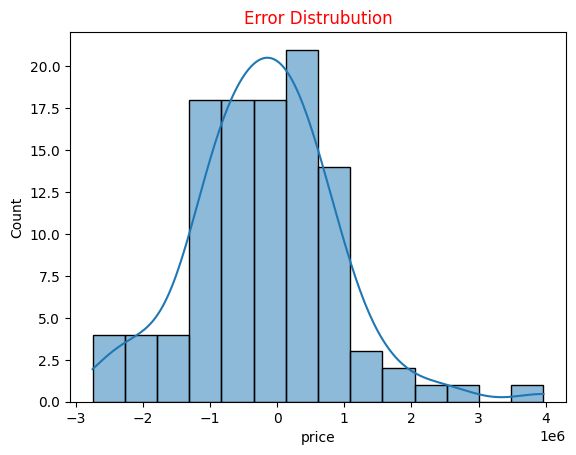

In [65]:
errors=y_test-y_pred

sns.histplot(errors,kde=True)
plt.title("Error Distrubution", color="red")
plt.show()


In [66]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score (RF):", r2_score(y_test, y_pred_rf))

R2 Score (RF): 0.6119599545778553


In [68]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [69]:
feat_importance = pd.Series(importances, index=X_train.columns)

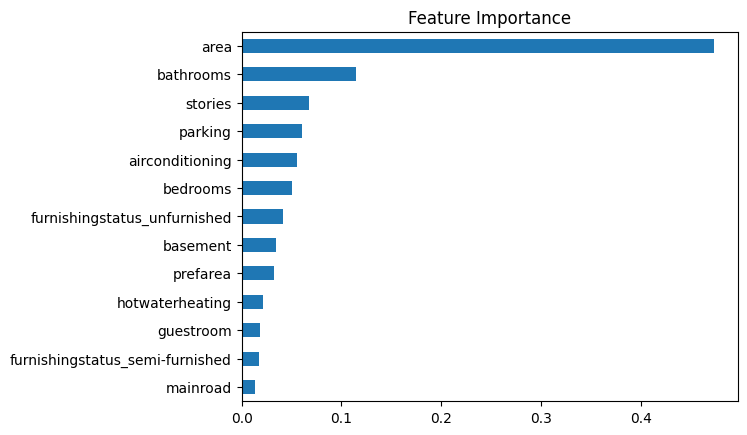

In [70]:
importances = rf.feature_importances_

feat_importance = pd.Series(importances, index=X_train.columns)
feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [71]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [2]:
import streamlit as st
import pickle
import numpy as np

st.write("App is running ✅")

model = pickle.load(open("model.pkl", "rb"))

st.title("🏠 House Price Prediction")

area = st.number_input("Area")
bedrooms = st.number_input("Bedrooms")
bathrooms = st.number_input("Bathrooms")
stories = st.number_input("Stories")

if st.button("Predict"):
    result = model.predict([[area, bedrooms, bathrooms, stories]])
    st.success(f"Predicted Price: {result[0]}")

In [7]:
import streamlit as st
import pickle
import numpy as np

# Load model
model = pickle.load(open("model.pkl", "rb"))

st.title("🏠 House Price Prediction")

# Numeric inputs
area = st.number_input("Area", min_value=0)
bedrooms = st.number_input("Bedrooms", min_value=0)
bathrooms = st.number_input("Bathrooms", min_value=0)
stories = st.number_input("Stories", min_value=0)
parking = st.number_input("Parking", min_value=0)

# Yes/No inputs
def yes_no(label):
    return 1 if st.selectbox(label, ["No", "Yes"]) == "Yes" else 0

mainroad = yes_no("Main Road")
guestroom = yes_no("Guest Room")
basement = yes_no("Basement")
hotwaterheating = yes_no("Hot Water Heating")
airconditioning = yes_no("Air Conditioning")
prefarea = yes_no("Preferred Area")

# Furnishing status (IMPORTANT)
furnishing = st.selectbox("Furnishing Status", 
                         ["Furnished", "Semi-Furnished", "Unfurnished"])

# Convert furnishing to dummy variables
furnishing_semi = 1 if furnishing == "Semi-Furnished" else 0
furnishing_unfurnished = 1 if furnishing == "Unfurnished" else 0

# Prediction
if st.button("Predict Price 💰"):
    
    features = np.array([[area, bedrooms, bathrooms, stories,
                          mainroad, guestroom, basement, hotwaterheating,
                          airconditioning, parking, prefarea,
                          furnishing_semi, furnishing_unfurnished]])

    result = model.predict(features)

    st.success(f"Predicted Price: ₹ {int(result[0]):,}")